# Configuraciones

In [ ]:
# Instalacion de dependencias
#!pip install langchain_openai langchain-qdrant qdrant-client

Configurar lo siguiente en el .env:
```
OPENAI_API_KEY=<API KEY de OpenAI>
QDRANT_URL=<URL de cluster de Qdrant>
QDRANT_KEY=<API KEY de Qdrant>
QDRANT_COLLECTION_NAME="prompting_caching_lab"
```

In [ ]:
# API Keys
from dotenv import load_dotenv
load_dotenv(override=True)

# Semantic Caching

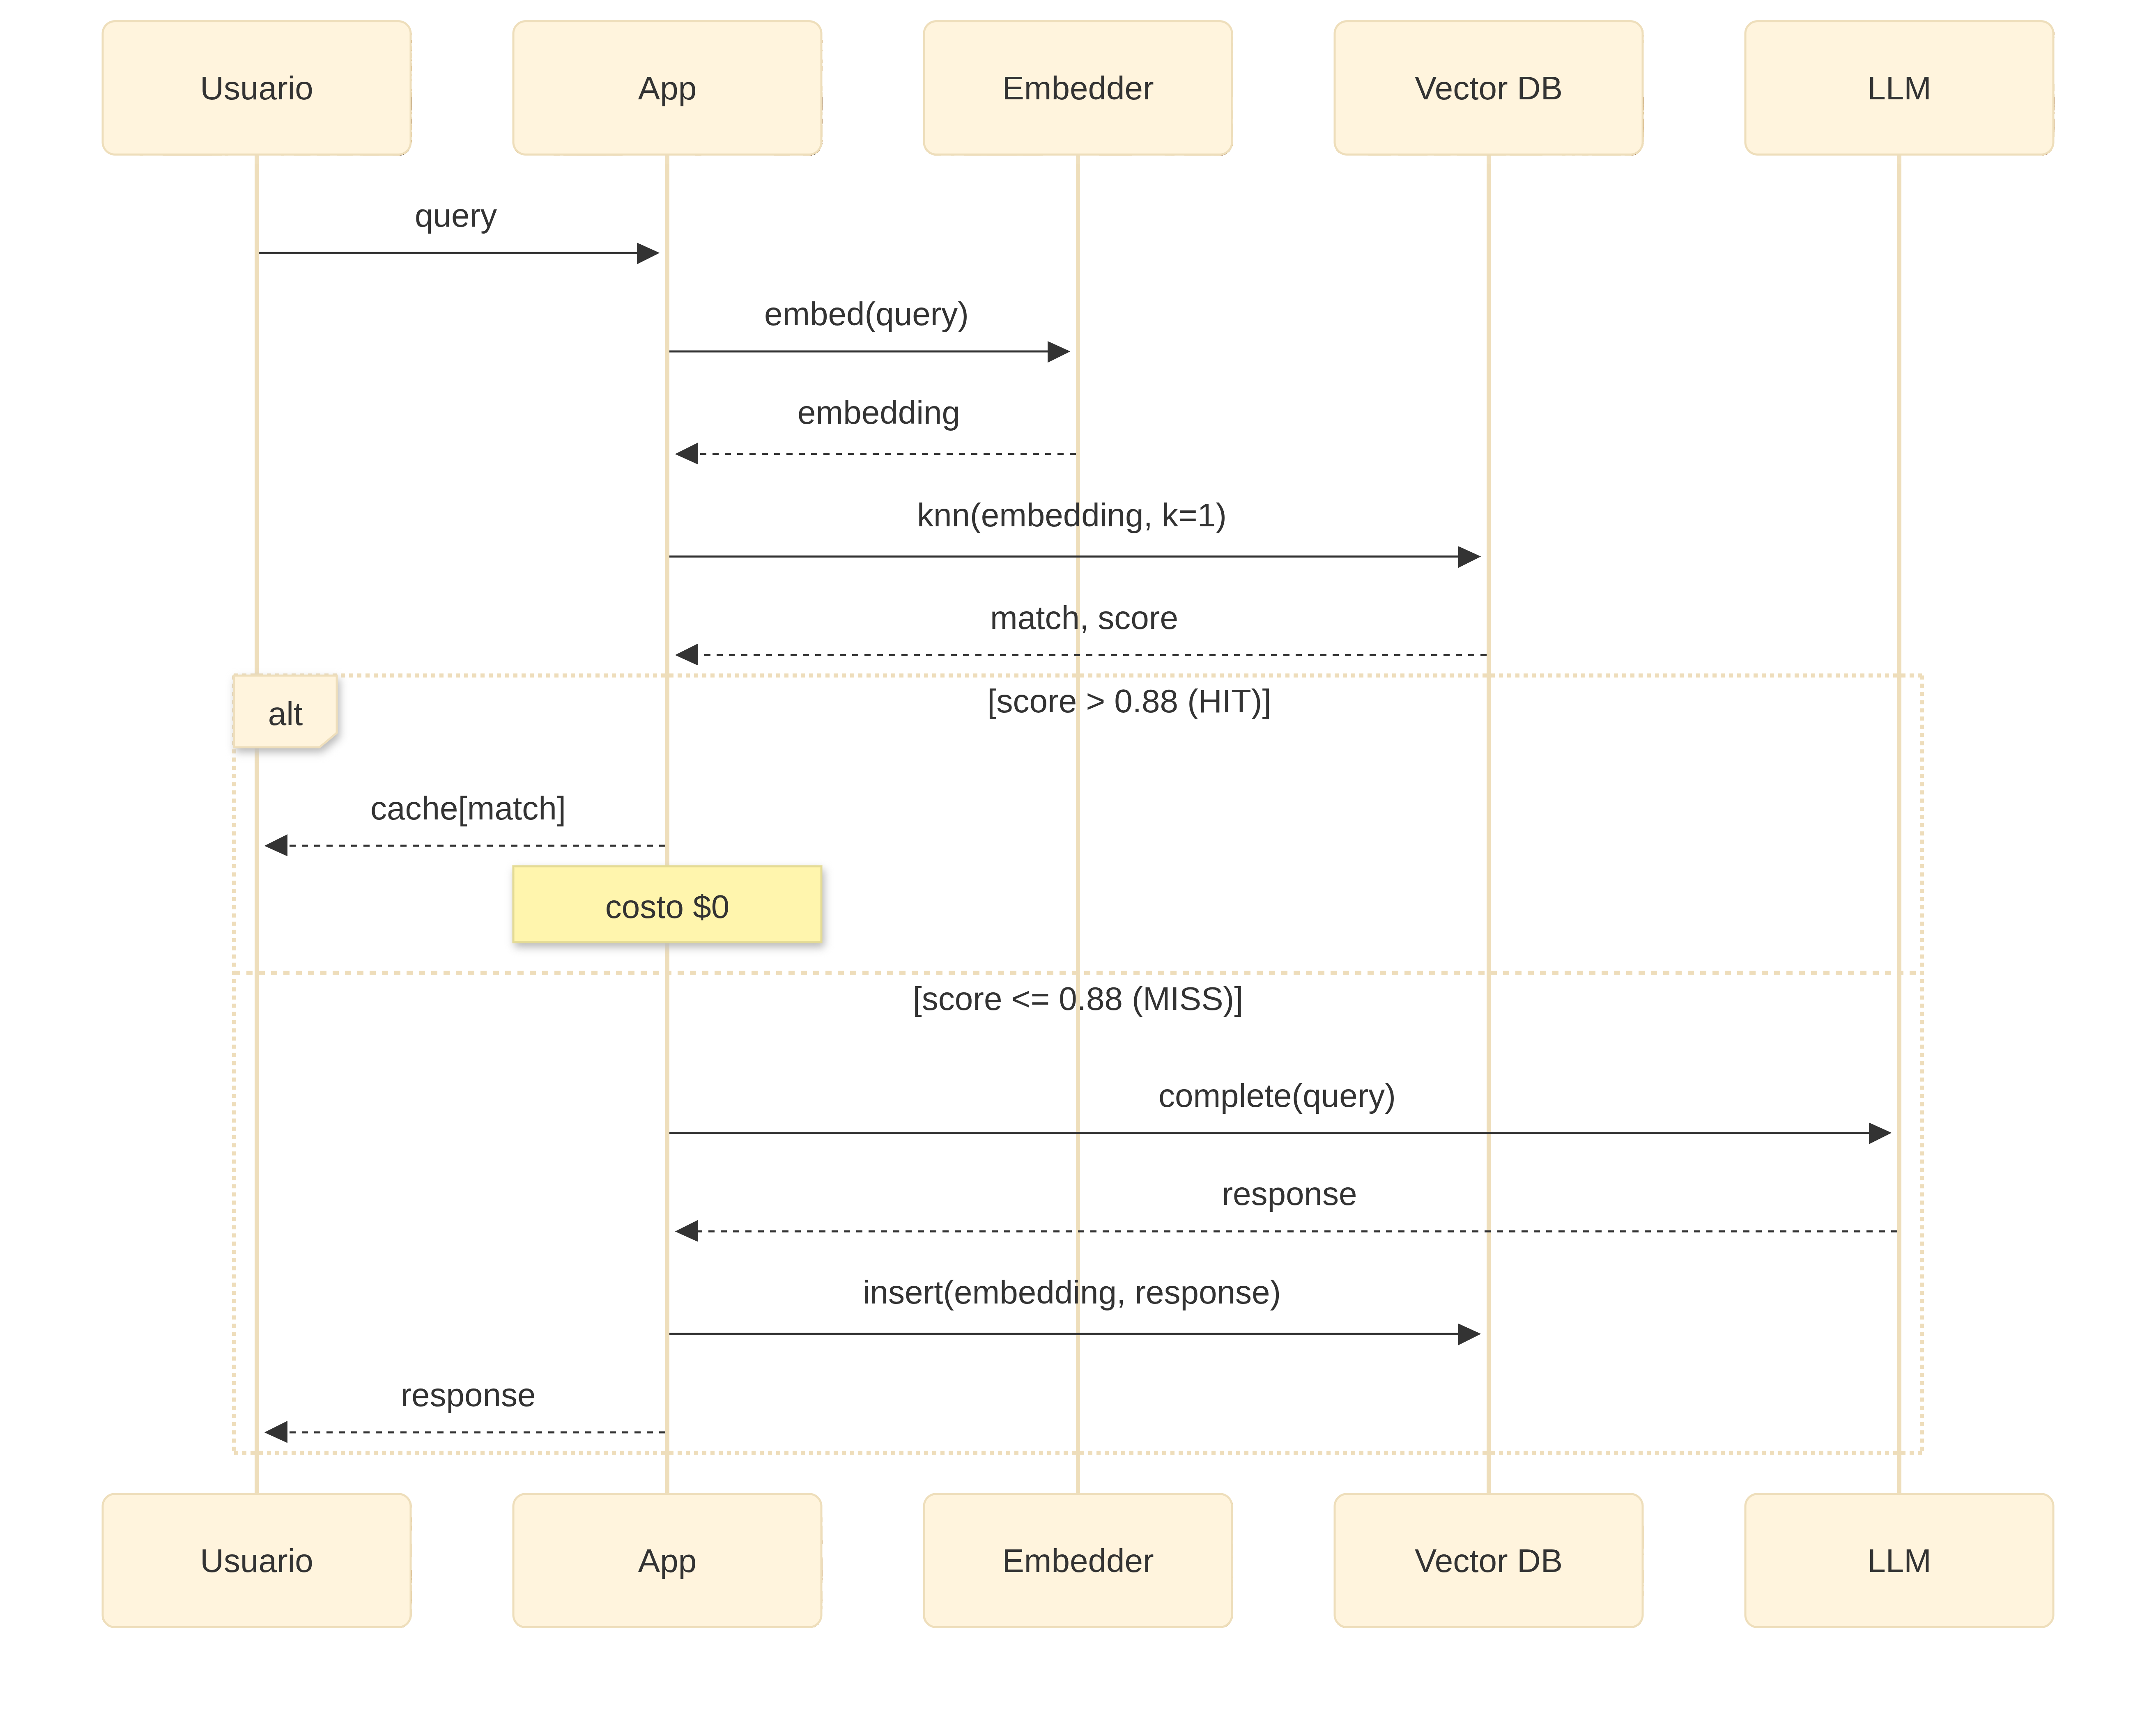

In [ ]:
# Modelo de inferencia
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7
)

In [ ]:
# Probar modeo de inferencia
response = llm.invoke("Que es la IA? dame la respuesta breve")
print(response.content)

In [ ]:
# Modelo de embeddings
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

In [ ]:
# Cliente de conexion a Qdrant
import os
from qdrant_client import QdrantClient

qdrant_url = os.getenv('QDRANT_URL')
qdrant_key = os.getenv('QDRANT_KEY')
collection_name = os.getenv('QDRANT_COLLECTION_NAME')

client = QdrantClient(
    url=qdrant_url,
    api_key=qdrant_key,
    timeout=60
)

In [ ]:
# Creación de la colección
from qdrant_client.http.models import Distance, VectorParams

client.create_collection(
    collection_name=collection_name,
    vectors_config=VectorParams(
        size=1536,  # dimensión del embedding
        distance=Distance.COSINE  # COSINE ideal para embeddings normalizados
    )
)

## Registrar preguntas en la BD Vectorial

In [ ]:
# Insercion de puntos en Qdrant
from langchain_qdrant import QdrantVectorStore
from langchain_core.documents import Document

doc = Document(
    page_content="Texto de prueba 2",
    metadata={"categoria": "Categoria 1"}
)

qdrant = QdrantVectorStore.from_documents(
    [doc],
    embeddings_model,
    url=qdrant_url,
    prefer_grpc=True,
    api_key=qdrant_key,
    collection_name=collection_name,
)

In [ ]:
# Función para registrar una nueva pregunta del prompt caching
def insertar_pregunta_cache(pregunta: str, respuesta: str) -> bool:
  doc = Document(
      page_content=pregunta,
      metadata={"respuesta": respuesta}
  )

  qdrant = QdrantVectorStore.from_documents(
      [doc],
      embeddings_model,
      url=qdrant_url,
      prefer_grpc=True,
      api_key=qdrant_key,
      collection_name=collection_name,
  )

In [ ]:
# Probar la función
resultado = insertar_pregunta_cache(
    "Cual es la capital de Francia?",
    "La capital de Francia es Paris"
)
resultado

## Consultar preguntas en la BD Vectorial

In [ ]:
# Objeto de recuperación
vector_store = QdrantVectorStore(
    client=client,
    collection_name=collection_name,
    embedding=embeddings_model
)

In [ ]:
retrieved_docs = vector_store.similarity_search_with_score( #similarity_search/similarity_search_with_score
    "texto",  # Usa directamente la pregunta
    k=1,
    score_threshold=0.88
)

In [ ]:
import json

for i, (doc, score) in enumerate(retrieved_docs, start=1):
    print(f"--- Resultado {i} ---")
    print(f"Score: {score:.4f}")
    print(f"Pregunta: {doc.page_content}")
    print("Metadata:")
    print(json.dumps(doc.metadata, indent=4, ensure_ascii=False))
    print(f"Metadata respuesta: {doc.metadata.get('respuesta')}")
    print()

In [ ]:
# Función para buscar la pregunta mas similar
def obtener_pregunta_mas_similar(pregunta: str, umbral: float = 0.6) -> (str, str):
  retrieved_docs = vector_store.similarity_search( #similarity_search/similarity_search_with_score
      pregunta,  # Usa directamente la pregunta
      k=1,
      score_threshold=umbral
  )

  if not retrieved_docs:
    return None, None

  doc = retrieved_docs[0]

  pregunta_similar = doc.page_content
  respuesta = doc.metadata.get("respuesta")

  return pregunta_similar, respuesta


In [ ]:
# Prueba
pregunta_similar, respuesta = obtener_pregunta_mas_similar("Francia que capital tiene?")
print(f"Pregunta similar: {pregunta_similar}")
print(f"Respuesta: {respuesta}")

## Prompting cache a prueba

In [ ]:
def responder_pregunta(pregunta: str) -> str:
  # Paso 1: Buscar si hay preguntas similares
  pregunta_similar, respuesta = obtener_pregunta_mas_similar(pregunta)

  # Paso 2: Si hay pregunta similar, retornar la respuesta guardada
  if pregunta_similar:
    print("--LOG-- Pregunta similar encontrada")
    return respuesta

  # Paso 3: Si no hay, obtener respuesta del LLM
  print("--LOG-- Genera nueva respuesta")
  nueva_respuesta = llm.invoke(pregunta)
  nueva_respuesta = nueva_respuesta.content

  # Paso 4: Registrar la pregunta/respuesta en la BD Vectorial
  resultado = insertar_pregunta_cache( pregunta, nueva_respuesta)

  # Paso 5: Retornar la nueva respuesta
  return nueva_respuesta

In [ ]:
respuesta = responder_pregunta("Quien gano el ultimo mundial?")
respuesta

# Trazabilidad

In [ ]:
#!pip install -U langchain langchain_openai

Configurar lo siguiente en el .env:
```
LANGSMITH_TRACING=true
LANGSMITH_ENDPOINT=https://api.smith.langchain.com
LANGSMITH_API_KEY=<your-api-key>
LANGSMITH_PROJECT="default"
```

In [ ]:
load_dotenv(override=True)

In [ ]:
# Probar modeo de inferencia
response = llm.invoke("Que es la IA? dame la respuesta breve")
print(response.content)

In [ ]:
from langchain.agents import create_agent


def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"


agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[get_weather],
    system_prompt="You are a helpful assistant",
)

# Run the agent
agent.invoke(
    {"messages": [{"role": "user", "content": "What is the weather in San Francisco?"}]}
)

In [ ]:
def build_config(team: str, feature: str, tenant_id: str, env: str, run_name: str = None):
    return {
        "tags": [f"team:{team}", f"feature:{feature}", f"env:{env}"],
        "metadata": {
            "team": team,
            "feature": feature,
            "tenant_id": tenant_id,
            "env": env,
        },
        # run_name es opcional: le da un nombre legible a la traza en vez de "ChatOpenAI"
        "run_name": run_name or f"{feature}-{team}",
    }

config_ejemplo = build_config(
    team="growth",
    feature="resumen-tickets",
    tenant_id="acme-corp",
    env="prod",
)
config_ejemplo

In [ ]:
respuesta = llm.invoke(
    "Resume en 2 líneas por qué un usuario podría cancelar su suscripción.",
    config=config_ejemplo,
)
print(respuesta)

In [ ]:
escenarios = [
    {
        "team": "growth",
        "feature": "resumen-tickets",
        "tenant_id": "acme-corp",
        "env": "prod",
        "prompt": "Resume en una línea: el cliente reporta que la app se cierra al subir una foto de perfil.",
    },
    {
        "team": "growth",
        "feature": "resumen-tickets",
        "tenant_id": "globex-inc",
        "env": "prod",
        "prompt": "Resume en una línea: el cliente pide reembolso porque el envío llegó tarde.",
    },
    {
        "team": "payments",
        "feature": "deteccion-fraude",
        "tenant_id": "acme-corp",
        "env": "prod",
        "prompt": "¿Esta transacción parece sospechosa? Monto: $9,999. Ubicación: distinta al país habitual del usuario.",
    },
    {
        "team": "payments",
        "feature": "deteccion-fraude",
        "tenant_id": "initech",
        "env": "staging",
        "prompt": "¿Esta transacción parece sospechosa? Monto: $12. Ubicación: la misma de siempre.",
    },
    {
        "team": "support",
        "feature": "chatbot-onboarding",
        "tenant_id": "globex-inc",
        "env": "dev",
        "prompt": "Dame un saludo de bienvenida corto para un nuevo usuario que se acaba de registrar.",
    },
]

for escenario in escenarios:
    cfg = build_config(
        team=escenario["team"],
        feature=escenario["feature"],
        tenant_id=escenario["tenant_id"],
        env=escenario["env"],
    )
    resp = llm.invoke(escenario["prompt"], config=cfg)
    print(f"[{escenario['team']} | {escenario['feature']} | {escenario['tenant_id']} | {escenario['env']}]")
    print(f"  -> {resp.content}\n")

# Routing

In [ ]:
from langchain_openai import ChatOpenAI

MODELOS_POR_NIVEL = {
    "simple": "gpt-4.1-nano",
    "medio": "gpt-4.1-mini",
    "complejo": "gpt-4.1",
}

_cache_llms = {}

def get_llm(nombre_modelo: str, temperature: float = 0.3) -> ChatOpenAI:
    """Devuelve (y cachea) una instancia de ChatOpenAI para el modelo dado."""
    key = (nombre_modelo, temperature)
    if key not in _cache_llms:
        _cache_llms[key] = ChatOpenAI(model=nombre_modelo, temperature=temperature)
    return _cache_llms[key]

## Clasificador 1 — Reglas (longitud + keywords)

**Criterios definidos para este laboratorio:**

- **Longitud del texto** (en caracteres):
  - `< 60` → tiende a *simple*
  - `60 - 180` → tiende a *medio*
  - `> 180` → tiende a *complejo*

- **Palabras clave / patrones**:
  - **Simple**: preguntas factuales puntuales → `qué es`, `cuánto es`, `capital de`, `define`, `traduce`, `significado de`, `cómo se dice`
  - **Medio**: piden explicación o comparación moderada → `explica`, `compara`, `diferencia entre`, `resume`, `cómo funciona`, `ventajas y desventajas`, `pasos para`
  - **Complejo**: requieren razonamiento profundo, diseño o código extenso → `diseña`, `arquitectura`, `optimiza`, `demuestra`, `implementa`, `analiza en profundidad`, `algoritmo`, `código completo`, `modelo matemático`, `prueba que`, `estrategia`

Se calcula un **puntaje** combinando ambas señales (keywords pesan más que la longitud, porque el tema importa más que el tamaño del texto) y se mapea a uno de los 3 niveles.

In [ ]:
import re

PALABRAS_SIMPLE = [
    "qué es", "que es", "cuánto es", "cuanto es", "capital de",
    "define", "traduce", "cómo se dice", "como se dice", "significado de",
]

PALABRAS_MEDIO = [
    "explica", "compara", "diferencia entre", "resume",
    "cómo funciona", "como funciona", "ventajas y desventajas", "pasos para",
]

PALABRAS_COMPLEJO = [
    "diseña", "disena", "arquitectura", "optimiza", "demuestra",
    "implementa", "analiza en profundidad", "algoritmo", "código completo",
    "codigo completo", "modelo matemático", "modelo matematico",
    "prueba que", "estrategia", "desde cero",
]


def clasificador_reglas(pregunta: str) -> str:
    """Clasifica la complejidad usando solo longitud + keywords (sin LLM)."""
    texto = pregunta.lower()
    longitud = len(pregunta)
    score = 0

    if any(p in texto for p in PALABRAS_COMPLEJO):
        score += 2
    if any(p in texto for p in PALABRAS_MEDIO):
        score += 1
    if any(p in texto for p in PALABRAS_SIMPLE):
        score -= 1

    if longitud > 180:
        score += 2
    elif longitud > 60:
        score += 1
    else:
        score -= 1

    if score <= -1:
        return "simple"
    elif score <= 1:
        return "medio"
    else:
        return "complejo"


# Prueba rápida
for p in ["¿Qué es la fotosíntesis?", "Explica la diferencia entre TCP y UDP",
          "Diseña la arquitectura completa de un sistema de microservicios con balanceo de carga, colas de mensajes y observabilidad, desde cero"]:
    print(f"[{clasificador_reglas(p)}] {p}")

## Clasificador 2 — Intención (LLM: `gpt-4.1-nano`)

Aquí no miramos longitud ni keywords: le pedimos a un modelo pequeño (`gpt-4.1-nano`) que **entienda el tema/intención** de la pregunta y decida su complejidad, devolviendo una salida estructurada con `with_structured_output` (Pydantic).

**Criterios que le damos al modelo vía system prompt:**

- **simple**: hechos puntuales, definiciones, datos directos, conversación casual, traducciones cortas. No requiere razonamiento en varios pasos.
- **medio**: requiere explicar un concepto, comparar 2-3 elementos, resumir, dar pasos de un proceso moderado, o redactar un texto corto.
- **complejo**: requiere razonamiento multi-paso, diseño de sistemas/arquitecturas, matemáticas o código no trivial, análisis que cruza varios dominios, o una respuesta larga y estructurada (informe, ensayo extenso, etc.).

In [ ]:
from typing import Literal
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage

class ClasificacionTema(BaseModel):
    """Clasificación de complejidad de una pregunta según su tema/intención."""
    nivel: Literal["simple", "medio", "complejo"] = Field(
        description="Nivel de complejidad del tema de la pregunta"
    )
    razon: str = Field(description="Breve justificación (una frase) del nivel elegido")


SYSTEM_PROMPT_CLASIFICADOR = """Eres un clasificador de complejidad de preguntas para un sistema de routing de modelos LLM.

Clasifica la pregunta del usuario en uno de estos 3 niveles, según el TEMA e INTENCIÓN (no la longitud del texto):

- simple: hechos puntuales, definiciones, datos directos, small talk, traducciones cortas. No requiere razonamiento en varios pasos.
- medio: requiere explicar un concepto, comparar 2-3 elementos, resumir, listar pasos de un proceso moderado, o redactar un texto corto.
- complejo: requiere razonamiento multi-paso, diseño de sistemas/arquitecturas, matemáticas o código no trivial, análisis que cruza varios dominios, o una respuesta larga y muy estructurada.

Responde SIEMPRE con la clasificación estructurada solicitada."""

_clasificador_llm_base = get_llm("gpt-4.1-nano", temperature=0)
_clasificador_llm_structured = _clasificador_llm_base.with_structured_output(ClasificacionTema)


def clasificador_llm(pregunta: str) -> str:
    """Clasifica la complejidad usando un modelo pequeño (gpt-4.1-nano) que entiende el tema."""
    resultado: ClasificacionTema = _clasificador_llm_structured.invoke(
        [SystemMessage(content=SYSTEM_PROMPT_CLASIFICADOR), HumanMessage(content=pregunta)]
    )
    return resultado.nivel


# Prueba rápida
for p in ["Hola, ¿cómo estás?", "Resume las causas de la Primera Guerra Mundial",
          "Demuestra matemáticamente por qué el algoritmo de Dijkstra no funciona con pesos negativos"]:
    print(f"[{clasificador_llm(p)}] {p}")

## Router genérico

El router recibe la **función clasificadora** como parámetro (`clasificador_reglas` o `clasificador_llm`) — así podemos intercambiarlas sin tocar el resto del pipeline.

In [ ]:
def responder_pregunta(pregunta: str, clasificador, verbose: bool = True) -> dict:
    """
    1. Usa `clasificador(pregunta)` para obtener el nivel de complejidad.
    2. Elige el modelo correspondiente en MODELOS_POR_NIVEL.
    3. Genera la respuesta con ese modelo.
    """
    nivel = clasificador(pregunta)
    modelo_nombre = MODELOS_POR_NIVEL[nivel]
    llm = get_llm(modelo_nombre)

    respuesta = llm.invoke(pregunta)

    resultado = {
        "pregunta": pregunta,
        "nivel": nivel,
        "modelo": modelo_nombre,
        "respuesta": respuesta.content,
    }
    if verbose:
        print(f"Pregunta:  {pregunta}")
        print(f"Nivel:     {resultado['nivel']}")
        print(f"Modelo:    {resultado['modelo']}")
        print(f"Respuesta: {resultado['respuesta'][:300]}")
        print("-" * 80)
    return resultado

In [ ]:
preguntas_prueba = [
    # Simples
    "¿Cuál es la capital de Perú?",
    "¿Qué es un algoritmo?",
    "Traduce 'good morning' al español",
    # Medias
    "Explica la diferencia entre memoria RAM y almacenamiento SSD",
    "Compara React y Vue para un proyecto pequeño",
    "Resume los pasos para hacer una taza de café espresso",
    # Complejas
    "Diseña la arquitectura de un sistema de recomendación en tiempo real para un e-commerce, incluyendo almacenamiento, cache y modelo de ML",
    "Implementa y explica desde cero un algoritmo de ordenamiento externo (external merge sort) para archivos que no caben en memoria",
    "Analiza en profundidad las implicancias macroeconómicas de subir la tasa de interés en un país con alta dolarización de su deuda",
]

## Comparación de los 2 clasificadores (sin generar respuesta todavía)

Primero comparamos únicamente el **nivel** que asigna cada clasificador, para ver dónde coinciden y dónde difieren.

In [ ]:
import pandas as pd

filas = []
for p in preguntas_prueba:
    nivel_reglas = clasificador_reglas(p)
    nivel_llm = clasificador_llm(p)
    filas.append({
        "pregunta": p,
        "nivel_reglas": nivel_reglas,
        "modelo_reglas": MODELOS_POR_NIVEL[nivel_reglas],
        "nivel_llm": nivel_llm,
        "modelo_llm": MODELOS_POR_NIVEL[nivel_llm],
        "coinciden": nivel_reglas == nivel_llm,
    })

df_comparacion = pd.DataFrame(filas)
df_comparacion

In [ ]:
print("=== Router usando Clasificador 1 (reglas) ===\n")
resultados_reglas = [responder_pregunta(p, clasificador=clasificador_reglas) for p in preguntas_prueba]

In [ ]:
print("=== Router usando Clasificador 2 (LLM / intención) ===\n")
resultados_llm = [responder_pregunta(p, clasificador=clasificador_llm) for p in preguntas_prueba]

In [ ]:
df_final = pd.DataFrame({
    "pregunta": [r["pregunta"] for r in resultados_reglas],
    "modelo (reglas)": [r["modelo"] for r in resultados_reglas],
    "modelo (llm)": [r["modelo"] for r in resultados_llm],
})
df_final